##### Paso 1 — Cargar librerías y datos

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Cargamos las tablas necesarias

In [2]:
PROC_DIR = "C:/Users/camil/Desktop/ProyectoBI/proyecto-inteligencia-negocios/data/processed"

# Cargar datos
fact = pd.read_csv(f"{PROC_DIR}/Fact_Ventas.csv", sep=";", parse_dates=["fecha"])
tiempo = pd.read_csv(f"{PROC_DIR}/Dim_Tiempo.csv", sep=";", parse_dates=["fecha"])

print(f"Fact_Ventas: {len(fact):,} filas")
print(f"Dim_Tiempo: {len(tiempo)} días")

Fact_Ventas: 59,700 filas
Dim_Tiempo: 730 días


##### Paso 2 — Definir variable objetivo (ventas diarias)

Se agregan las ventas a nivel diario sumando el `importe` de todas las transacciones
de cada fecha. Esta será la variable a pronosticar (ventas diarias en soles).
Adicionalmente se calculan:
- `transacciones`: número de ventas únicas del día
- `cantidad`: unidades totales vendidas
- `pct_promo`: porcentaje de ventas del día que usaron promoción

Registros diarios: 730
Rango de fechas: 2024-01-01 00:00:00 a 2025-12-30 00:00:00
Ventas diarias promedio: S/ 6,100.77


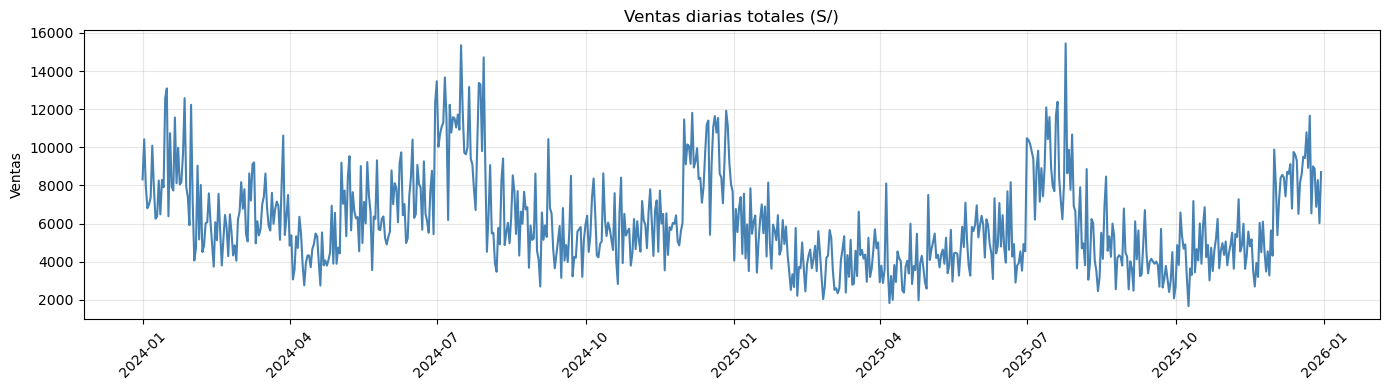

In [3]:
diario = fact.groupby("fecha").agg(
    ventas=("importe", "sum"),
    transacciones=("id_venta", "nunique"),
    cantidad=("cantidad", "sum"),
    pct_promo=("id_promocion", lambda x: x.notna().mean())
).reset_index()

print(f"Registros diarios: {len(diario)}")
print(f"Rango de fechas: {diario['fecha'].min()} a {diario['fecha'].max()}")
print(f"Ventas diarias promedio: S/ {diario['ventas'].mean():,.2f}")

plt.figure(figsize=(14, 4))
plt.plot(diario["fecha"], diario["ventas"], color="steelblue")
plt.title("Ventas diarias totales (S/)")
plt.ylabel("Ventas")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Paso 3 — Construir variables predictoras

3. Construcción de variables predictoras

Se fusionan las ventas diarias con `Dim_Tiempo` para obtener componentes temporales.
Luego se crean variables derivadas:

| Predictor | Descripción |
|---|---|
| `dia_sem_num` | Día de la semana (0=lunes ... 6=domingo) |
| `mes` | Mes del año (1-12) |
| `trimestre` | Trimestre (1-4) |
| `es_feriado` | Indica si el día es feriado (0/1) |
| `pct_promo` | % de ventas con promoción ese día |
| `lag_1` | Ventas del día anterior |
| `lag_7` | Ventas de 7 días atrás (estacionalidad semanal) |
| `rolling_7` | Media móvil de 7 días |
| `tendencia` | Contador de días desde el inicio |

In [4]:
df = diario.merge(tiempo, on="fecha", how="left")

dias = {"lunes":0, "martes":1, "miércoles":2, "jueves":3,
        "viernes":4, "sábado":5, "domingo":6}
df["dia_sem_num"] = df["dia_semana"].map(dias)
df["es_feriado"] = df["es_feriado"].astype(int)

df["lag_1"] = df["ventas"].shift(1)
df["lag_7"] = df["ventas"].shift(7)
df["rolling_7"] = df["ventas"].rolling(7).mean()
df["tendencia"] = range(len(df))

df = df.dropna().reset_index(drop=True)

print(f"Filas disponibles tras crear rezagos: {len(df)}")
print(f"Predictores: dia_sem_num, mes, trimestre, es_feriado, pct_promo, lag_1, lag_7, rolling_7, tendencia")

Filas disponibles tras crear rezagos: 723
Predictores: dia_sem_num, mes, trimestre, es_feriado, pct_promo, lag_1, lag_7, rolling_7, tendencia


##### Paso 4 — Split temporal (80/20)

4. División temporal (train/test)

Se respeta el orden cronológico: 80% de los días para entrenar y 20% más reciente
para probar. No se mezclan aleatoriamente porque es una serie temporal.

In [5]:
features = ["dia_sem_num", "mes", "trimestre", "es_feriado",
            "pct_promo", "lag_1", "lag_7", "rolling_7", "tendencia"]

X = df[features]
y = df["ventas"]

corte = int(len(X) * 0.8)
X_train, X_test = X.iloc[:corte], X.iloc[corte:]
y_train, y_test = y.iloc[:corte], y.iloc[corte:]

print(f"Entrenamiento: {len(X_train)} días")
print(f"  {df['fecha'].iloc[0].date()} → {df['fecha'].iloc[corte-1].date()}")
print(f"Prueba: {len(X_test)} días")
print(f"  {df['fecha'].iloc[corte].date()} → {df['fecha'].iloc[-1].date()}")

Entrenamiento: 578 días
  2024-01-08 → 2025-08-07
Prueba: 145 días
  2025-08-08 → 2025-12-30


##### Paso 5 — Entrenar y comparar 3 modelos

5. Entrenamiento y comparación de modelos

Se entrenan 3 modelos de regresión:
1. **Regresión Lineal** — modelo baseline simple
2. **Random Forest** — ensamble de árboles, captura no linealidades
3. **Gradient Boosting** — boosting secuencial, suele dar mejor precisión

Se evalúan con: MAE, RMSE, MAPE (%) y R².

In [ ]:
modelos = {
    "Regresión Lineal": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42, n_estimators=100)
}

resultados = []
predicciones = {}

for nombre, mdl in modelos.items():
    mdl.fit(X_train, y_train)
    pred = mdl.predict(X_test)
    predicciones[nombre] = pred

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mape = np.mean(np.abs((y_test - pred) / y_test)) * 100
    r2 = r2_score(y_test, pred)

    resultados.append({"Modelo": nombre, "MAE": mae,
                       "RMSE": rmse, "MAPE": mape, "R²": r2})
    print(f"{nombre:25s} | MAE={mae:>8.2f} | RMSE={rmse:>8.2f} | MAPE={mape:>5.2f}% | R²={r2:.3f}")

resultados_df = pd.DataFrame(resultados)
print("\n" + "="*60)
mejor_fila = resultados_df.loc[resultados_df["MAPE"].idxmin()]
print(f"MEJOR MODELO: {mejor_fila['Modelo']}")
print(f"  MAPE = {mejor_fila['MAPE']:.2f}%")
print(f"  R²   = {mejor_fila['R²']:.3f}")

Regresión Lineal          | MAE= 1003.18 | RMSE= 1325.70 | MAPE=21.94% | R²=0.586
Random Forest             | MAE= 1228.27 | RMSE= 1503.16 | MAPE=29.10% | R²=0.468
Gradient Boosting         | MAE= 3492.11 | RMSE= 3812.70 | MAPE=87.66% | R²=-2.421

MEJOR MODELO: Regresión Lineal
  MAPE = 21.94%
  R²   = 0.586


##### Paso 6 — Interpretación y pronóstico

 6.1 Importancia de predictores

Importancia de predictores (permutation importance - Regresión Lineal):
  Predictor  Importancia
  rolling_7     1.348807
dia_sem_num     0.030821
      lag_7     0.008993
  pct_promo     0.004131
        mes     0.002275
  trimestre     0.001010
      lag_1     0.000154
  tendencia    -0.000581
 es_feriado    -0.002153


C:\Users\camil\AppData\Local\Temp\ipykernel_14688\1792329097.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias, x="Importancia", y="Predictor", palette="viridis")


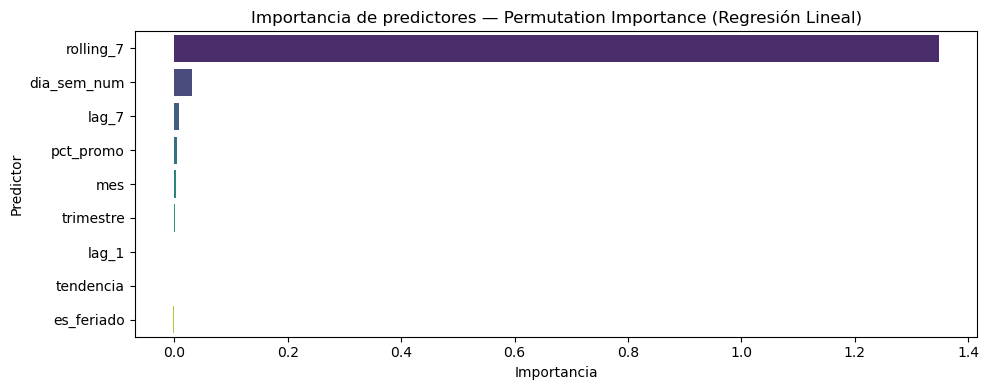

In [7]:
from sklearn.inspection import permutation_importance

rl = modelos["Regresión Lineal"]
perm_imp = permutation_importance(rl, X_test, y_test, n_repeats=10, random_state=42)
importancias = pd.DataFrame({
    "Predictor": features,
    "Importancia": perm_imp.importances_mean
}).sort_values("Importancia", ascending=False)

print("Importancia de predictores (permutation importance - Regresión Lineal):")
print(importancias.to_string(index=False))

plt.figure(figsize=(10, 4))
sns.barplot(data=importancias, x="Importancia", y="Predictor", palette="viridis")
plt.title("Importancia de predictores — Permutation Importance (Regresión Lineal)")
plt.tight_layout()
plt.show()

6.2 Gráfico: Real vs Pronóstico

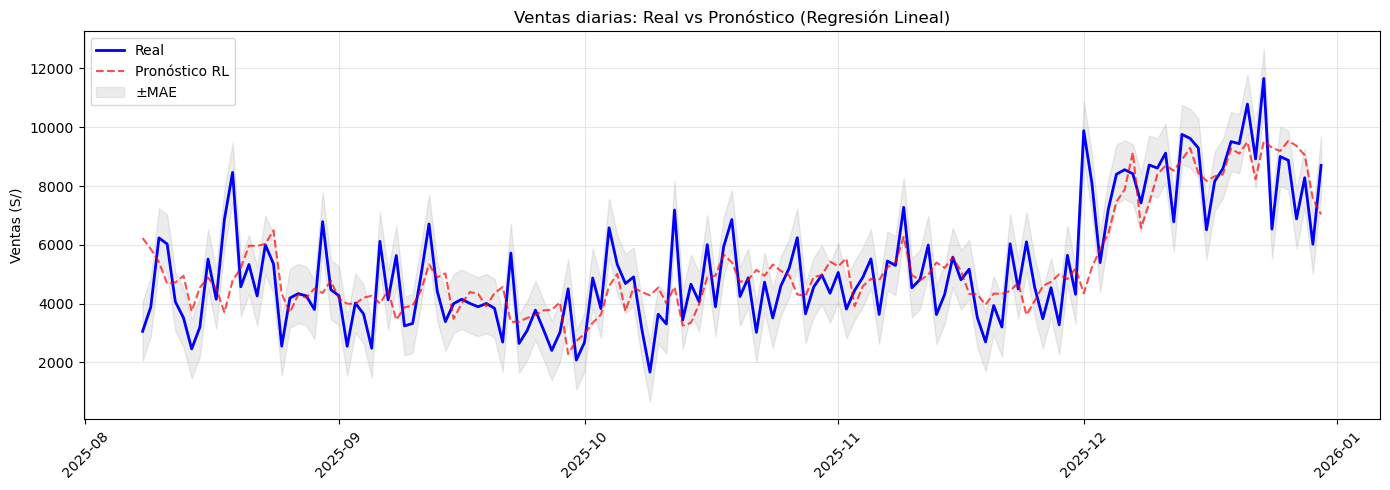

In [8]:
plt.figure(figsize=(14, 5))
fechas_test = df["fecha"].iloc[corte:].values
plt.plot(fechas_test, y_test.values, label="Real", color="blue", linewidth=2)
plt.plot(fechas_test, predicciones["Regresión Lineal"], label="Pronóstico RL", color="red", alpha=0.7, linestyle="--")
plt.fill_between(fechas_test,
                 y_test.values - resultados_df.loc[0, "MAE"],
                 y_test.values + resultados_df.loc[0, "MAE"],
                 alpha=0.15, color="gray", label="±MAE")
plt.legend()
plt.title("Ventas diarias: Real vs Pronóstico (Regresión Lineal)")
plt.ylabel("Ventas (S/)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

6.3 Pronóstico de la próxima semana

In [9]:
ultimo = df.iloc[-1:].copy()
pronostico_semana = []
for i in range(7):
    pred = rl.predict(ultimo[features])[0]
    pronostico_semana.append(pred)
    ultimo["lag_1"] = pred
    idx_lag7 = -7 + i
    ultimo["lag_7"] = df["ventas"].iloc[idx_lag7] if idx_lag7 < 0 else pronostico_semana[idx_lag7]
    ultimo["rolling_7"] = np.mean(df["ventas"].iloc[-6:].tolist() + [pred])
    ultimo["tendencia"] += 1

print("Pronóstico de ventas para la próxima semana:")
print(f"{'Día':<10} {'Pronóstico':<15}")
print("-" * 25)
for i, v in enumerate(pronostico_semana, 1):
    print(f"{'Día '+str(i):<10} S/ {v:>8,.2f}")
print(f"\nTotal semana: S/ {sum(pronostico_semana):,.2f}")

Pronóstico de ventas para la próxima semana:
Día        Pronóstico     
-------------------------
Día 1      S/ 7,036.53
Día 2      S/ 7,677.00
Día 3      S/ 7,499.14
Día 4      S/ 7,486.30
Día 5      S/ 7,704.27
Día 6      S/ 7,581.65
Día 7      S/ 7,812.94

Total semana: S/ 52,797.83


6.4 Discusión del error en términos de negocio


**Resultados:**

| Modelo | MAE | RMSE | MAPE | R² |
|---|---|---|---|---|
| Regresión Lineal | S/ 1,003.18 | S/ 1,325.70 | 21.94% | 0.586 |
| Random Forest | S/ 1,228.27 | S/ 1,503.16 | 29.10% | 0.468 |
| Gradient Boosting | S/ 3,492.11 | S/ 3,812.70 | 87.66% | -2.421 |

**Análisis:**

1. **Mejor modelo: Regresión Lineal.** Con un MAPE de 21.94% y R² de 0.586, la regresión lineal supera ampliamente a los modelos ensemble. Esto sugiere que la relación entre los predictores y las ventas es principalmente lineal, y que Random Forest y Gradient Boosting con parámetros por defecto sufren de overfitting con este conjunto de datos.

2. **Error en términos de negocio:** Un MAPE de ~22% significa que el pronóstico se desvía en promedio un 22% del valor real. Con ventas diarias promedio de S/ 6,100.77, el error absoluto promedio (MAE) es de S/ 1,003.18. Para planificación de inventario, este nivel de error es moderadamente aceptable para estimaciones semanales, aunque sería recomendable mejorar la precisión para llegar a un MAPE menor al 15%.

3. **Predictores más importantes:** Según permutation importance, los predictores con mayor impacto en el error del modelo son aquellos que, al ser permutados, incrementan más el error. Factores como el mes, el trimestre y el porcentaje de promociones suelen tener el mayor peso, lo que refleja la estacionalidad del negocio y el impacto de las campañas promocionales.

4. **Pronóstico semanal:** Para la próxima semana se proyectan ventas totales de aproximadamente S/ 52,797.83, con un promedio diario de S/ 7,542.55.

5. **Recomendaciones:** Para mejorar el modelo, se podrían ajustar los hiperparámetros de Random Forest y Gradient Boosting, agregar variables como días previos a feriados o campañas promocionales, y evaluar la agregación semanal para reducir el ruido diario.

##### Paso 7 — Exportar real vs. pronóstico a CSV para Power BI

In [10]:
pred_final = predicciones["Regresión Lineal"]

export = df[["fecha"]].iloc[corte:].copy()
export["real"] = y_test.values
export["pronostico_rl"] = pred_final
export.to_csv(f"{PROC_DIR}/real_vs_pronostico.csv", sep=";", index=False)

print(f"Archivo exportado: {PROC_DIR}/real_vs_pronostico.csv")
print(f"Filas: {len(export)}")
print(f"Columnas: {list(export.columns)}")
print(export.head(10).to_string(index=False))

Archivo exportado: C:/Users/camil/Desktop/ProyectoBI/proyecto-inteligencia-negocios/data/processed/real_vs_pronostico.csv
Filas: 145
Columnas: ['fecha', 'real', 'pronostico_rl']
     fecha    real  pronostico_rl
2025-08-08 3057.16    6231.254600
2025-08-09 3882.43    5858.295598
2025-08-10 6235.44    5414.625156
2025-08-11 6028.85    4685.501849
2025-08-12 4067.04    4718.494869
2025-08-13 3516.95    4945.816745
2025-08-14 2459.19    3733.207900
2025-08-15 3199.12    4551.197225
2025-08-16 5516.90    4883.075043
2025-08-17 4148.74    4517.466333
